I explored some additional datasets to look for useful variables for the crime prediction model.
Some potential interesting factors to research later are transport hubs and housing related variables such as rent/ownership.
<br>
The data used for this notebook can be downloaded at: https://www.kaggle.com/datasets/meganvandrunen/data-correlation-test/data?select=LSOA_2021_EW_BSC_V4.cpg
<br>
Put the data in the notebooks folder named data_correlation_test

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
import geopandas as gpd
import os
import glob
import folium

Information about the deprivation dataset can be found here: https://deprivation.communities.gov.uk/glossary
<br>
age and gender: https://www.ons.gov.uk/peoplepopulationandcommunity/populationandmigration/populationestimates/datasets/lowersuperoutputareamidyearpopulationestimatesnationalstatistics
<br>
dataset postcode to LSOA: https://geoportal.statistics.gov.uk/datasets/7fc55d71a09d4dcfa1fd6473138aacc3/about
<br>
dataset schools: https://get-information-schools.service.gov.uk/Downloads
<br>
geospatial data: https://geoportal.statistics.gov.uk/datasets/ons::lower-layer-super-output-areas-december-2021-boundaries-ew-bsc-v4-2/about

In [2]:
# Read the data
df_street_crimes = pd.read_csv("data_correlation_test/combined_data.csv")
print("Street crime data has been read")
df_deprivation = pd.read_csv("data_correlation_test/deprivation.csv")
print("Deprivation data has been read")
df_age_gender_2023 = pd.read_csv("data_correlation_test/age_gender_2023.csv", sep=";")
print("Age and gender 2023 data has been read")
df_age_gender_2024 = pd.read_csv("data_correlation_test/age_gender_2024.csv", sep=";")
print("Age and gender data 2024 has been read")

df_school = pd.read_csv("data_correlation_test/schools_LSOA_5_may_2026.csv", sep=",",encoding="cp1252",
    usecols=["LSOA (code)", "EstablishmentStatus (name)","PhaseOfEducation (name)"]
)
print("School data has been read")

# Not used, but maybe usefull later
df_postcode_lsoa = pd.read_csv("data_correlation_test/Postcode_LSOA.csv")
print("Postcode data has been read")

Street crime data has been read
Deprivation data has been read
Age and gender 2023 data has been read
Age and gender data 2024 has been read
School data has been read


C:\Users\20243092\AppData\Local\Temp\ipykernel_21512\1597908722.py:17: DtypeWarning: Columns (0: ladnmw) have mixed types. Specify dtype option on import or set low_memory=False.
  df_postcode_lsoa = pd.read_csv("data_correlation_test/Postcode_LSOA.csv")


Postcode data has been read


In the street_crimes dataset, the column 'Context' contains only missing values, so it is removed.
Since the goal is to forecast the number of crimes and their types per LSOA, we remove rows where LSOA information is missing .

In [3]:
if "Context" in df_street_crimes.columns:
    df_street_crimes = df_street_crimes.drop(columns=["Context"])
df_street_crimes = df_street_crimes.dropna(subset=["LSOA name", "LSOA code"])

In [4]:
df_street_crimes.info(show_counts=True, memory_usage="deep")

<class 'pandas.DataFrame'>
Index: 17190446 entries, 0 to 17880939
Data columns (total 11 columns):
 #   Column                 Non-Null Count     Dtype  
---  ------                 --------------     -----  
 0   Crime ID               14392669 non-null  str    
 1   Month                  17190446 non-null  str    
 2   Reported by            17190446 non-null  str    
 3   Falls within           17190446 non-null  str    
 4   Longitude              17190446 non-null  float64
 5   Latitude               17190446 non-null  float64
 6   Location               17190446 non-null  str    
 7   LSOA code              17190446 non-null  str    
 8   LSOA name              17190446 non-null  str    
 9   Crime type             17190446 non-null  str    
 10  Last outcome category  14392669 non-null  str    
dtypes: float64(2), str(9)
memory usage: 11.7 GB


In [5]:
df_deprivation.info(show_counts=True, memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 33755 entries, 0 to 33754
Data columns (total 24 columns):
 #   Column                                                      Non-Null Count  Dtype
---  ------                                                      --------------  -----
 0   LSOA code (2021)                                            33755 non-null  str  
 1   LSOA name (2021)                                            33755 non-null  str  
 2   Local Authority District code (2024)                        33755 non-null  str  
 3   Local Authority District name (2024)                        33755 non-null  str  
 4   Index of Multiple Deprivation (IMD) Rank                    33755 non-null  int64
 5   Index of Multiple Deprivation (IMD) Decile                  33755 non-null  int64
 6   Income Rank                                                 33755 non-null  int64
 7   Income Decile                                               33755 non-null  int64
 8   Employment Rank            

In [6]:
# Remove columns with LAD, since only need LSOA
if "LAD 2021 Code" in df_age_gender_2024.columns:
    df_age_gender_2024 = df_age_gender_2024.drop(columns=["LAD 2021 Code"])

if "LAD 2021 Name" in df_age_gender_2024.columns:
    df_age_gender_2024 = df_age_gender_2024.drop(columns=["LAD 2021 Name"])

if "LAD 2023 Code" in df_age_gender_2023.columns:
    df_age_gender_2023 = df_age_gender_2023.drop(columns=["LAD 2023 Code"])

if "LAD 2023 Name" in df_age_gender_2023.columns:
    df_age_gender_2023 = df_age_gender_2023.drop(columns=["LAD 2023 Name"])

In [7]:
df_age_gender_2023.info(show_counts=True, memory_usage="deep")
df_age_gender_2023.head()

<class 'pandas.DataFrame'>
RangeIndex: 35717 entries, 0 to 35716
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   LSOA 2021 Code  35672 non-null  str    
 1   LSOA 2021 Name  35672 non-null  str    
 2   Total           35672 non-null  float64
 3   F0 to 15        35672 non-null  float64
 4   F16 to 29       35672 non-null  float64
 5   F30 to 44       35672 non-null  float64
 6   F45 to 64       35672 non-null  float64
 7   F65 and over    35672 non-null  float64
 8   M0 to 15        35672 non-null  float64
 9   M16 to 29       35672 non-null  float64
 10  M30 to 44       35672 non-null  float64
 11  M45 to 64       35672 non-null  float64
 12  M65 and over    35672 non-null  float64
dtypes: float64(11), str(2)
memory usage: 7.7 MB


,LSOA 2021 Code,LSOA 2021 Name,Total,F0 to 15,F16 to 29,F30 to 44,F45 to 64,F65 and over,M0 to 15,M16 to 29,M30 to 44,M45 to 64,M65 and over
0,E01011949,Hartlepool 009A,1.925,181.0,173.0,206.0,258.0,171.0,217.0,187.0,175.0,227.0,130.0
1,E01011950,Hartlepool 008A,1.177,120.0,80.0,126.0,136.0,96.0,128.0,81.0,148.0,174.0,88.0
2,E01011951,Hartlepool 007A,1.320,117.0,146.0,148.0,160.0,80.0,131.0,116.0,155.0,190.0,77.0
3,E01011952,Hartlepool 002A,1.670,189.0,143.0,168.0,206.0,202.0,199.0,120.0,116.0,196.0,131.0
4,E01011953,Hartlepool 002B,2.075,223.0,225.0,216.0,247.0,141.0,293.0,180.0,186.0,229.0,135.0


In [8]:
df_age_gender_2024.info(show_counts=True, memory_usage="deep")
df_age_gender_2024.head()

<class 'pandas.DataFrame'>
RangeIndex: 35672 entries, 0 to 35671
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   LSOA 2021 Code  35672 non-null  str    
 1   LSOA 2021 Name  35672 non-null  str    
 2   Total           35672 non-null  float64
 3   F0 to 15        35672 non-null  float64
 4   F16 to 29       35672 non-null  float64
 5   F30 to 44       35672 non-null  float64
 6   F45 to 64       35672 non-null  int64  
 7   F65 and over    35672 non-null  int64  
 8   M0 to 15        35672 non-null  float64
 9   M16 to 29       35672 non-null  float64
 10  M30 to 44       35672 non-null  float64
 11  M45 to 64       35672 non-null  int64  
 12  M65 and over    35672 non-null  int64  
dtypes: float64(7), int64(4), str(2)
memory usage: 7.7 MB


,LSOA 2021 Code,LSOA 2021 Name,Total,F0 to 15,F16 to 29,F30 to 44,F45 to 64,F65 and over,M0 to 15,M16 to 29,M30 to 44,M45 to 64,M65 and over
0,E01011949,Hartlepool 009A,1.898,170.0,157.0,194.0,264,179,202.0,191.0,174.0,232,135
1,E01011950,Hartlepool 008A,1.247,159.0,76.0,148.0,120,103,146.0,85.0,151.0,178,81
2,E01011951,Hartlepool 007A,1.393,125.0,141.0,168.0,168,85,136.0,129.0,161.0,202,78
3,E01011952,Hartlepool 002A,1.669,183.0,140.0,172.0,203,203,197.0,125.0,128.0,192,126
4,E01011953,Hartlepool 002B,2.303,256.0,263.0,242.0,284,144,339.0,198.0,208.0,229,140


<Figure size 1000x600 with 0 Axes>

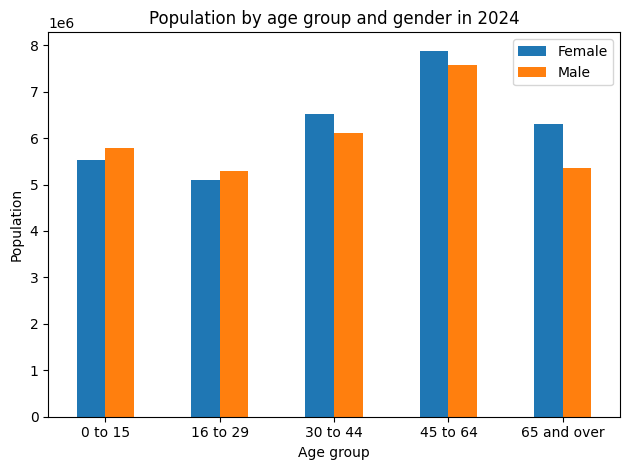

In [9]:
totals = df_age_gender_2024.iloc[:, 3:].sum()

age_groups = ["0 to 15", "16 to 29", "30 to 44", "45 to 64", "65 and over"]

plot_df = pd.DataFrame({
    "Female": [totals[f"F{age}"] for age in age_groups],
    "Male": [totals[f"M{age}"] for age in age_groups]
}, index=age_groups)

plt.figure(figsize=(10, 6))
plot_df.plot(kind="bar")

plt.ylabel("Population")
plt.xlabel("Age group")
plt.title("Population by age group and gender in 2024")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Since 2021 there are 33,755 LSOAs in England and 1,917 in Wales. This is in total 35.672. As we can see below, the street crimes data set has more than that. Why? Wales has 59  and England 15 to many LSOA codes, did boundaries change? maybe typo's?
source: https://www.ons.gov.uk/methodology/geography/ukgeographies/statisticalgeographies 

In [10]:
num_distinct_lsoa_crimes = df_street_crimes["LSOA code"].nunique()
print(f"The street crimes data set has {num_distinct_lsoa_crimes} distinct LSOA codes")
num_distinct_lsoa_depr = df_deprivation["LSOA code (2021)"].nunique()
print(f"The deprivation data set has {num_distinct_lsoa_depr} distinct LSOA codes")

print(df_street_crimes["LSOA code"].str[0].value_counts())
print(df_street_crimes["LSOA code"].dropna().drop_duplicates().str[0].value_counts())

The street crimes data set has 35746 distinct LSOA codes
The deprivation data set has 33755 distinct LSOA codes
LSOA code
E    16319980
W      870466
Name: count, dtype: int64
LSOA code
E    33770
W     1976
Name: count, dtype: int64


In [11]:
# Filter only on crime data of England
if "LSOA code (2021)" in df_deprivation.columns:
    england_lsoas = set(df_deprivation["LSOA code (2021)"])
else:
    england_lsoas = set(df_deprivation["LSOA code"])

df_crimes = df_street_crimes[df_street_crimes["LSOA code"].isin(england_lsoas)]
num_distinct_lsoa_crimes_england = df_crimes["LSOA code"].nunique()
print(len(england_lsoas))
print(num_distinct_lsoa_crimes_england)
print(f"There are {len(england_lsoas)-num_distinct_lsoa_crimes_england} LSOA's in England where no crimes are recorded")

33755
32856
There are 899 LSOA's in England where no crimes are recorded


In [12]:
# Drop column 'LSOA name' of df_street_crime, so that there are no mismatches when merging. 
# The names of deprivation dataset can be trusted more since it is complete and verified.
df_crimes = df_crimes.drop(columns=["LSOA name"], errors="ignore")

df_age_gender_2023 = df_age_gender_2023.drop(columns=["LSOA 2021 Name"], errors="ignore")
df_age_gender_2024 = df_age_gender_2024.drop(columns=["LSOA 2021 Name"], errors="ignore")

In [13]:
# Rename columns of deprivation, so can be merged
if "LSOA code (2021)" in df_deprivation.columns:
    df_deprivation = df_deprivation.rename(columns={
        "LSOA code (2021)": "LSOA code",
        "LSOA name (2021)": "LSOA name"
    })

df_merged = df_crimes.merge(
    df_deprivation,
    on="LSOA code",
    how="left"
)

# Check for correct shape
print(df_crimes.shape)
print(df_merged.shape)

# Rename columns of age_gender
if "LSOA 2021 Code" in df_age_gender_2024.columns:
    df_age_gender_2024 = df_age_gender_2024.rename(columns={
        "LSOA 2021 Code": "LSOA code",
        "LSOA 2021 Name": "LSOA name"
    })

df_merged = df_merged.merge(
    df_age_gender_2024,
    on="LSOA code",
    how="left"
)
print(df_merged.shape)

df_merged.head()

(16240808, 10)
(16240808, 33)
(16240808, 44)


,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,Crime type,Last outcome category,...,F0 to 15,F16 to 29,F30 to 44,F45 to 64,F65 and over,M0 to 15,M16 to 29,M30 to 44,M45 to 64,M65 and over
0,a9e67112895dee54af5fdfb03b1196df2ade54ef9a4562...,2023-03,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-2.492876,51.422716,On or near Trajectus Way,E01014399,Violence and sexual offences,Unable to prosecute suspect,...,296.0,152.0,367.0,284,380,265.0,198.0,344.0,251,283
1,2e8a39786d327a0ee5012c937c73d345727f17fd778f34...,2023-03,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-2.510372,51.423406,On or near Durley Lane,E01014399,Public order,Formal action is not in the public interest,...,296.0,152.0,367.0,284,380,265.0,198.0,344.0,251,283
2,55e85c975222172afd8b520ffad3c7e0d7505e773ec65f...,2023-03,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-2.492876,51.422716,On or near Trajectus Way,E01014399,Public order,Unable to prosecute suspect,...,296.0,152.0,367.0,284,380,265.0,198.0,344.0,251,283
3,29c72e6199b0302cb152846c59372d366d97db9ee3aeba...,2023-03,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-2.512071,51.409470,On or near Harlech Close,E01014399,Violence and sexual offences,Unable to prosecute suspect,...,296.0,152.0,367.0,284,380,265.0,198.0,344.0,251,283
4,6f44ecaeff6df6efe60b06305a34b092792dd012cbd5da...,2023-03,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-2.508867,51.416147,On or near St Francis Road,E01014399,Violence and sexual offences,Unable to prosecute suspect,...,296.0,152.0,367.0,284,380,265.0,198.0,344.0,251,283


In [14]:
df_merged.info(show_counts=True, memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 16240808 entries, 0 to 16240807
Data columns (total 44 columns):
 #   Column                                                      Non-Null Count     Dtype  
---  ------                                                      --------------     -----  
 0   Crime ID                                                    13601062 non-null  str    
 1   Month                                                       16240808 non-null  str    
 2   Reported by                                                 16240808 non-null  str    
 3   Falls within                                                16240808 non-null  str    
 4   Longitude                                                   16240808 non-null  float64
 5   Latitude                                                    16240808 non-null  float64
 6   Location                                                    16240808 non-null  str    
 7   LSOA code                                                   162

In [15]:
#Group by LSOA codes
analysis_df = (
    df_merged
    .groupby("LSOA code")
    .agg(
        crime_count=("Crime type", "size"),
        imd_rank=("Index of Multiple Deprivation (IMD) Rank", "first"),
        imd_decile=("Index of Multiple Deprivation (IMD) Decile", "first")
    )
    .reset_index()
)

analysis_df.head()

,LSOA code,crime_count,imd_rank,imd_decile
0,E01000001,580,26525,8
1,E01000002,1575,31203,10
2,E01000003,482,25913,8
3,E01000005,2677,14807,5
4,E01000006,318,10917,4


In [16]:
analysis_df.info(show_counts=True, memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 32856 entries, 0 to 32855
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   LSOA code    32856 non-null  str  
 1   crime_count  32856 non-null  int64
 2   imd_rank     32856 non-null  int64
 3   imd_decile   32856 non-null  int64
dtypes: int64(3), str(1)
memory usage: 2.8 MB


In [17]:
# Check for correlation
crime_counts = analysis_df["crime_count"].to_numpy()
imd_ranks = analysis_df["imd_rank"].to_numpy()
imd_deciles = analysis_df["imd_decile"].to_numpy()

print(scipy.stats.pearsonr(imd_ranks, crime_counts))    # Pearson's r
print(scipy.stats.pearsonr(imd_deciles, crime_counts))

print(scipy.stats.spearmanr(imd_ranks, crime_counts))   # Spearman's rho
print(scipy.stats.spearmanr(imd_deciles, crime_counts))

print(scipy.stats.kendalltau(imd_ranks, crime_counts))  # Kendall's tau
print(scipy.stats.kendalltau(imd_deciles, crime_counts))

PearsonRResult(statistic=-0.2954165750610404, pvalue=0.0)
PearsonRResult(statistic=-0.29324613843349584, pvalue=0.0)
SignificanceResult(statistic=-0.583215625030779, pvalue=0.0)
SignificanceResult(statistic=-0.5794040363763585, pvalue=0.0)
SignificanceResult(statistic=-0.41769378217090647, pvalue=0.0)
SignificanceResult(statistic=-0.4331156588800902, pvalue=0.0)


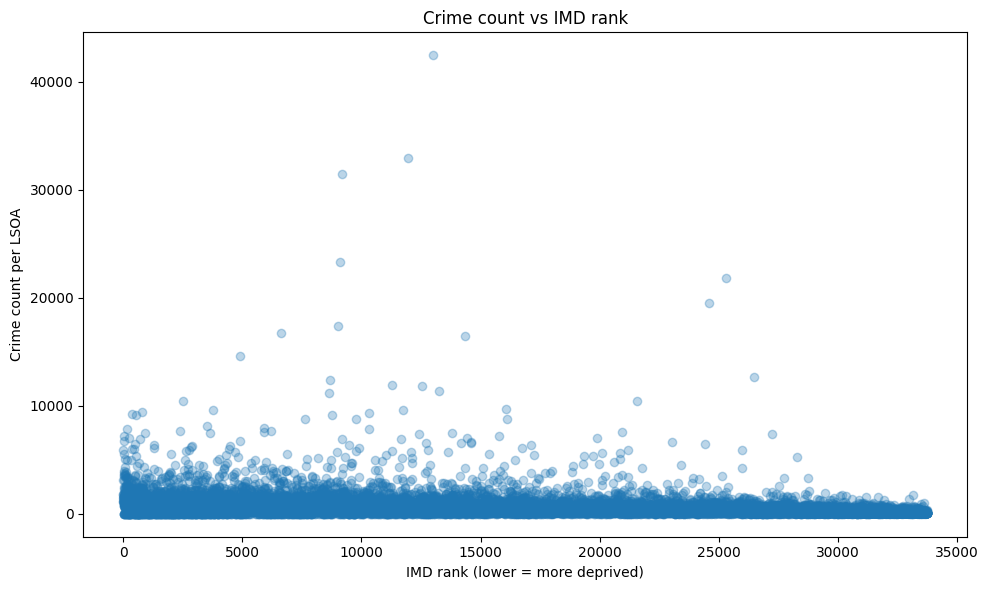

In [18]:
plt.figure(figsize=(10,6))
plt.scatter(analysis_df["imd_rank"], analysis_df["crime_count"], alpha=0.3)

plt.xlabel("IMD rank (lower = more deprived)")
plt.ylabel("Crime count per LSOA")
plt.title("Crime count vs IMD rank")

plt.tight_layout()
plt.show()

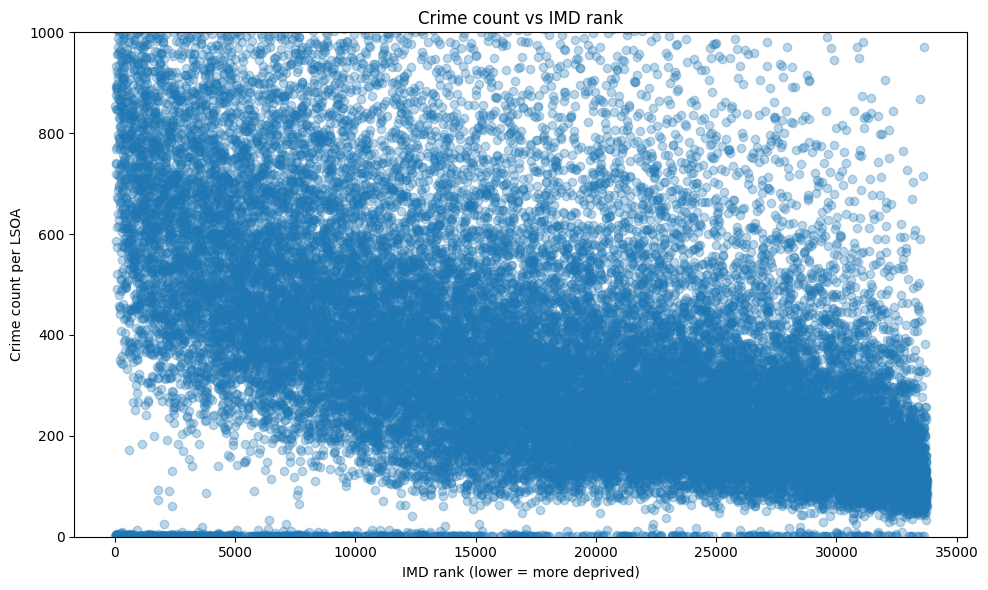

In [19]:
# If we zoom in in the plot above:
plt.figure(figsize=(10,6))
plt.scatter(analysis_df["imd_rank"], analysis_df["crime_count"], alpha=0.3)

plt.xlabel("IMD rank (lower = more deprived)")
plt.ylabel("Crime count per LSOA")
plt.ylim(0, 1000)
plt.title("Crime count vs IMD rank")

plt.tight_layout()
plt.show()

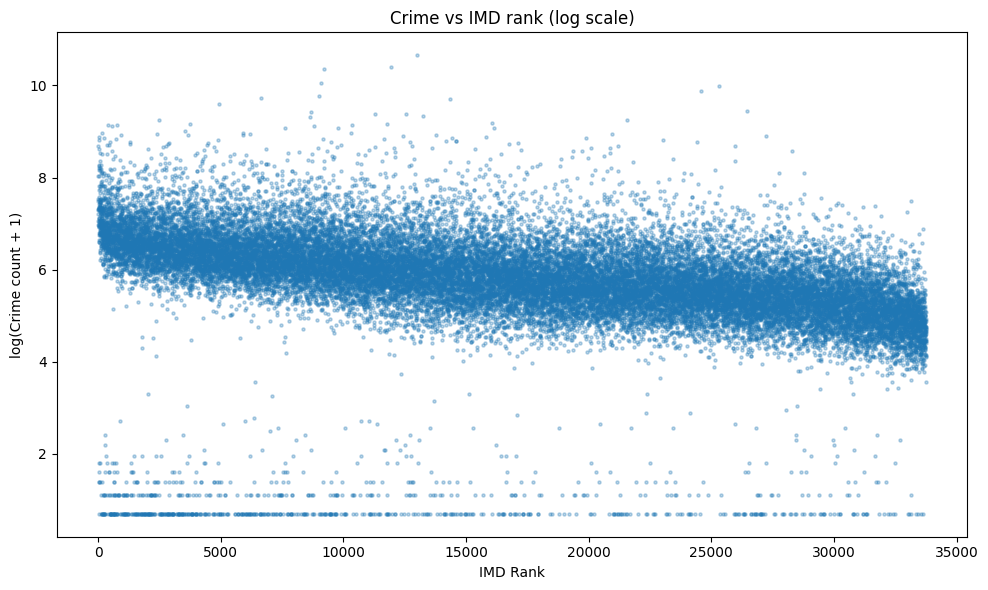

In [20]:
plt.figure(figsize=(10,6))
plt.scatter(
    analysis_df["imd_rank"],
    np.log1p(analysis_df["crime_count"]),
    alpha=0.3,
    s=5
)

plt.xlabel("IMD Rank")
plt.ylabel("log(Crime count + 1)")
plt.title("Crime vs IMD rank (log scale)")
plt.tight_layout()
plt.show()

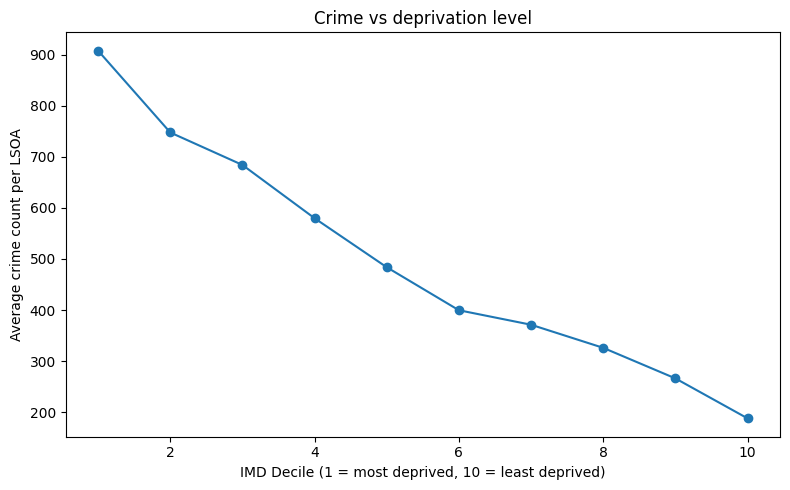

In [21]:
binned = analysis_df.groupby("imd_decile")["crime_count"].mean()

plt.figure(figsize=(8,5))
plt.plot(binned.index, binned.values, marker="o")

plt.xlabel("IMD Decile (1 = most deprived, 10 = least deprived)")
plt.ylabel("Average crime count per LSOA")
plt.title("Crime vs deprivation level")
plt.tight_layout()
plt.show()

In [22]:
df_crimes_2024 = df_crimes.copy()

df_crimes_2024 = df_crimes_2024[df_crimes_2024["Month"].str.startswith("2024")]

#Aggregate crimes per LSOA
df_age_2024_analysis = (
    df_crimes_2024
    .groupby("LSOA code")
    .size()
    .reset_index(name="crime_count")
)

df_age_2024_analysis = df_age_2024_analysis.merge(
    df_age_gender_2024,
    on="LSOA code",
    how="left"
)

df_corr_age_2024 = df_age_2024_analysis.drop(columns=["LSOA code"])

corr_matrix_2024 = df_corr_age_2024.corr()

corr_matrix_2024["crime_count"].sort_values(ascending=False)

crime_count     1.000000
M30 to 44       0.332255
F16 to 29       0.325351
M16 to 29       0.325131
F30 to 44       0.250743
F0 to 15        0.092251
M0 to 15        0.088372
M45 to 64       0.028664
Total           0.000618
F45 to 64      -0.084854
M65 and over   -0.194371
F65 and over   -0.196058
Name: crime_count, dtype: float64

In [23]:
df_crimes_2023 = df_crimes.copy()

df_crimes_2023 = df_crimes_2023[df_crimes_2023["Month"].str.startswith("2023")]


#Aggregate crimes per LSOA
df_age_2023_analysis = (
    df_crimes_2023
    .groupby("LSOA code")
    .size()
    .reset_index(name="crime_count")
)

# Rename columns of age_gender
if "LSOA 2021 Code" in df_age_gender_2023.columns:
    df_age_gender_2023 = df_age_gender_2023.rename(columns={
        "LSOA 2021 Code": "LSOA code",
        "LSOA 2021 Name": "LSOA name"
    })

df_age_2023_analysis = df_age_2023_analysis.merge(
    df_age_gender_2023,
    on="LSOA code",
    how="left"
)

df_corr_age_2023 = df_age_2023_analysis.drop(columns=["LSOA code"])

corr_matrix_2023_pearson = df_corr_age_2023.corr(method="pearson")
corr_matrix_2023_spearman = df_corr_age_2023.corr(method="spearman")
corr_matrix_2023_kendall = df_corr_age_2023.corr(method="kendall")

print("Pearson")
print(corr_matrix_2023_pearson["crime_count"].sort_values(ascending=False))
print("Spearman")
print(corr_matrix_2023_spearman["crime_count"].sort_values(ascending=False))
print("Kendall")
print(corr_matrix_2023_kendall["crime_count"].sort_values(ascending=False))

Pearson
crime_count     1.000000
F16 to 29       0.336981
M16 to 29       0.336263
M30 to 44       0.326494
F30 to 44       0.247156
F0 to 15        0.096103
M0 to 15        0.092057
M45 to 64       0.015144
Total           0.000518
F45 to 64      -0.097105
F65 and over   -0.203123
M65 and over   -0.204717
Name: crime_count, dtype: float64
Spearman
crime_count     1.000000
F16 to 29       0.561846
M16 to 29       0.529074
M30 to 44       0.503136
F30 to 44       0.485316
Total           0.351969
F0 to 15        0.332596
M0 to 15        0.329300
M45 to 64       0.041130
F45 to 64      -0.039137
F65 and over   -0.338998
M65 and over   -0.370580
Name: crime_count, dtype: float64
Kendall
crime_count     1.000000
F16 to 29       0.399675
M16 to 29       0.373669
M30 to 44       0.352665
F30 to 44       0.338515
Total           0.241573
F0 to 15        0.232228
M0 to 15        0.229898
M45 to 64       0.027895
F45 to 64      -0.025784
F65 and over   -0.229352
M65 and over   -0.249953
Name: c

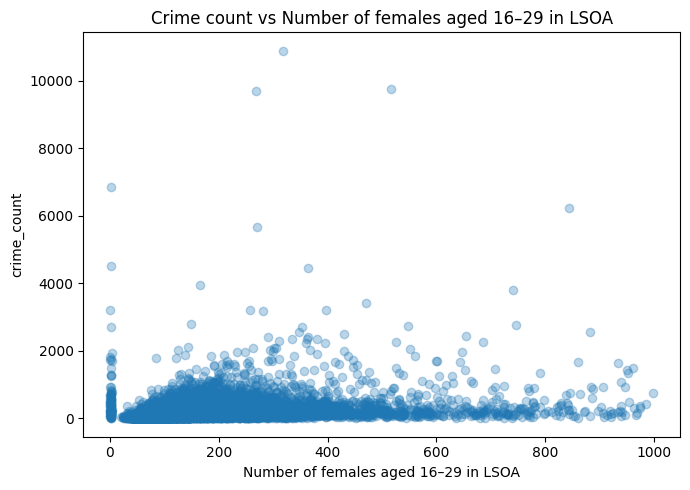

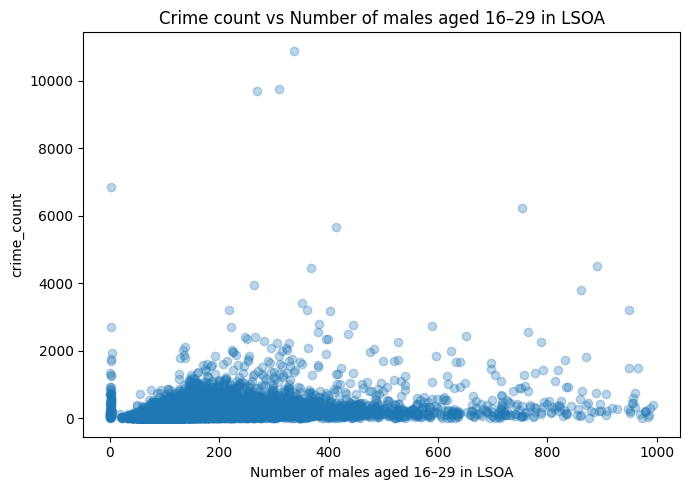

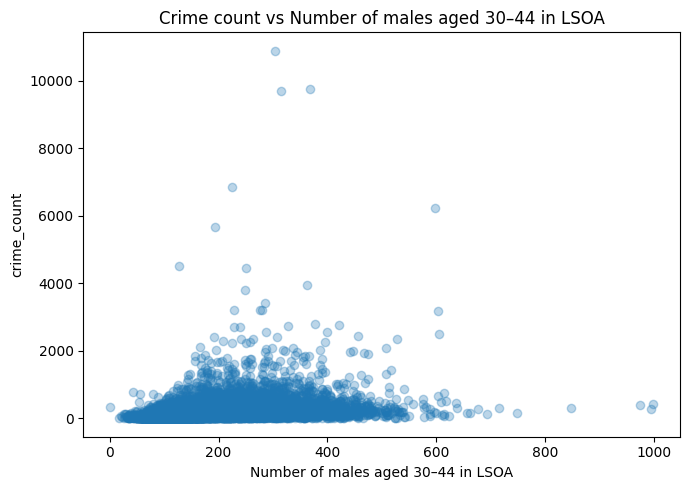

In [24]:
label_map = {
    "F16 to 29": "Number of females aged 16–29 in LSOA",
    "M16 to 29": "Number of males aged 16–29 in LSOA",
    "M30 to 44": "Number of males aged 30–44 in LSOA"
}

cols = ["F16 to 29", "M16 to 29", "M30 to 44"]

for col in cols:
    plt.figure(figsize=(7,5))
    plt.scatter(df_corr_age_2023[col], df_corr_age_2023["crime_count"], alpha=0.3)
    plt.xlabel(label_map[col])
    plt.ylabel("crime_count")
    plt.title(f"Crime count vs {label_map[col]}")
    plt.tight_layout()
    plt.show()

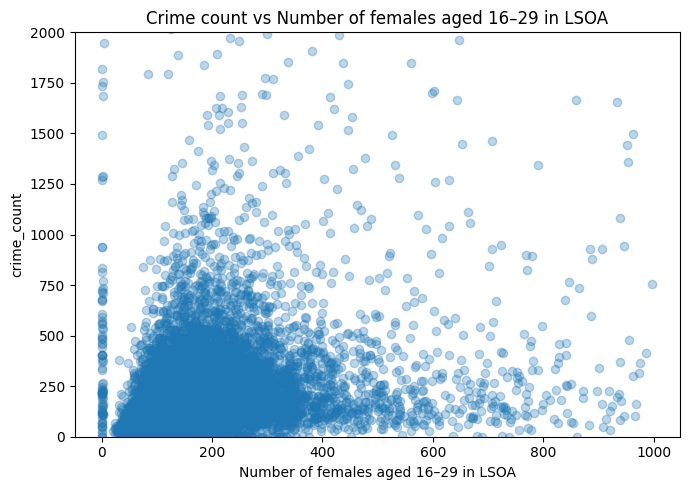

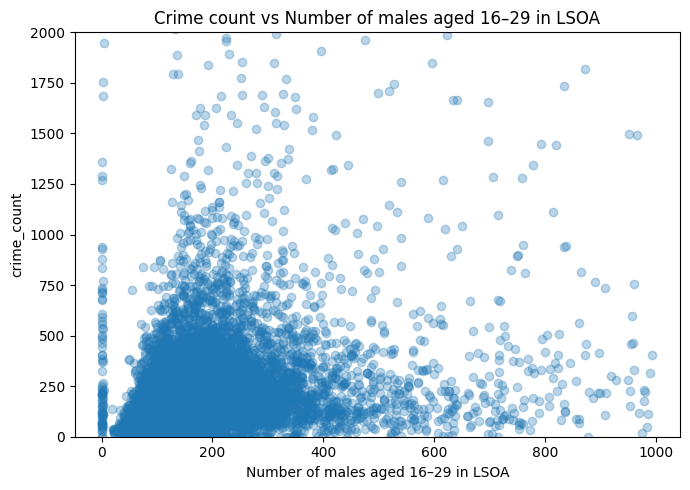

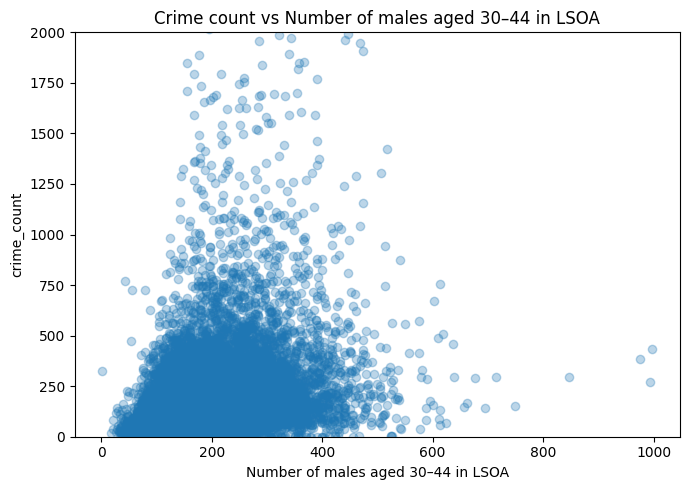

In [25]:
# When more zoomed in
label_map = {
    "F16 to 29": "Number of females aged 16–29 in LSOA",
    "M16 to 29": "Number of males aged 16–29 in LSOA",
    "M30 to 44": "Number of males aged 30–44 in LSOA"
}

cols = ["F16 to 29", "M16 to 29", "M30 to 44"]

for col in cols:
    plt.figure(figsize=(7,5))
    plt.scatter(df_corr_age_2023[col], df_corr_age_2023["crime_count"], alpha=0.3)
    plt.xlabel(label_map[col])
    plt.ylim(0,2000)
    plt.ylabel("crime_count")
    plt.title(f"Crime count vs {label_map[col]}")
    plt.tight_layout()
    plt.show()

In [26]:
df_school.info(show_counts=True, memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 52365 entries, 0 to 52364
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   EstablishmentStatus (name)  52365 non-null  str  
 1   PhaseOfEducation (name)     52365 non-null  str  
 2   LSOA (code)                 52365 non-null  str  
dtypes: str(3)
memory usage: 9.7 MB


In [27]:
print(df_school["LSOA (code)"].str[0].value_counts())
print(df_school["EstablishmentStatus (name)"].unique())
print(df_school["PhaseOfEducation (name)"].unique())
df_school.head(20)

LSOA (code)
E    48263
W     2467
9     1490
L       89
M       47
S        9
Name: count, dtype: int64
<StringArray>
['Open', 'Closed', 'Open, but proposed to close', 'Proposed to open']
Length: 4, dtype: str
<StringArray>
[                'Primary',          'Not applicable',
                 'Nursery',               'Secondary',
             'All-through', 'Middle deemed secondary',
   'Middle deemed primary',                 '16 plus']
Length: 8, dtype: str


,EstablishmentStatus (name),PhaseOfEducation (name),LSOA (code)
0,Open,Primary,E01032739
1,Open,Not applicable,E01000002
2,Open,Not applicable,E01032739
3,Open,Not applicable,E01032739
4,Closed,Nursery,E01000901
5,Open,Nursery,E01000937
6,Open,Not applicable,E01000887
7,Open,Not applicable,E01035710
8,Open,Primary,E01000941
9,Open,Primary,E01000873


In [28]:
# Filter out LSOA that are not in England and only count schools that are open. The data is updated everyday on the website.
df_school_count = (
    df_school[
        (df_school["EstablishmentStatus (name)"] == "Open") &
        (df_school["LSOA (code)"].str.startswith("E"))
    ]
    .groupby("LSOA (code)")
    .size()
    .reset_index(name="school_count")
    .rename(columns={"LSOA (code)": "LSOA code"})
)

In [29]:
df_crime_lsoa = (
    df_crimes
    .groupby("LSOA code")
    .size()
    .reset_index(name="crime_count")
)

df_school_crime_count = df_crime_lsoa.merge(
    df_school_count,
    on="LSOA code",
    how="left"
)

df_school_crime_count["school_count"] = df_school_crime_count["school_count"].fillna(0)
df_school_crime_count_val = df_school_crime_count.drop(columns=["LSOA code"])


In [30]:
corr_matrix_school_crime_count_pearson = df_school_crime_count_val.corr(method="pearson")
corr_matrix_school_crime_count_spearman = df_school_crime_count_val.corr(method="spearman")
corr_matrix_school_crime_count_kendall = df_school_crime_count_val.corr(method="kendall")

print("Pearson")
print(corr_matrix_school_crime_count_pearson["crime_count"].sort_values(ascending=False))
print("Spearman")
print(corr_matrix_school_crime_count_spearman["crime_count"].sort_values(ascending=False))
print("Kendall")
print(corr_matrix_school_crime_count_kendall["crime_count"].sort_values(ascending=False))

Pearson
crime_count     1.000000
school_count    0.052812
Name: crime_count, dtype: float64
Spearman
crime_count     1.000000
school_count    0.052458
Name: crime_count, dtype: float64
Kendall
crime_count     1.000000
school_count    0.040599
Name: crime_count, dtype: float64


In [31]:
df_crime_lsoa.head()

,LSOA code,crime_count
0,E01000001,580
1,E01000002,1575
2,E01000003,482
3,E01000005,2677
4,E01000006,318


In [32]:
base_path = "data_correlation_test/LSOA_location_info"
shapefiles = glob.glob(os.path.join(base_path, "**/*.shp"), recursive=True)

lsoa_gdfs = [gpd.read_file(shp) for shp in shapefiles]
lsoa_locations = gpd.GeoDataFrame(
    pd.concat(lsoa_gdfs, ignore_index=True),
    crs=lsoa_gdfs[0].crs
)

lsoa_location_count = lsoa_locations.merge(
    df_crime_lsoa,
    left_on="LSOA21CD",
    right_on="LSOA code",
    how="left"
)

print(lsoa_location_count["LSOA21CD"].dropna().drop_duplicates().str[0].value_counts())
lsoa_location_count.head()


LSOA21CD
E    33755
W     1917
Name: count, dtype: int64


,LSOA21CD,LSOA21NM,LSOA21NMW,BNG_E,BNG_N,LAT,LONG,GlobalID,geometry,LSOA code,crime_count
0,E01000001,City of London 001A,NaN,532123,181632,51.5182,-0.097150,3478c558-3297-4e2b-979e-e29dd9ff3bf5,"POLYGON ((532282.63 181906.496, 532248.249 181...",E01000001,580.0
1,E01000002,City of London 001B,NaN,532480,181715,51.5188,-0.091970,f2072109-b1ae-426c-b166-083cc32f1789,"POLYGON ((532746.813 181786.891, 532248.249 18...",E01000002,1575.0
2,E01000003,City of London 001C,NaN,532239,182033,51.5217,-0.095330,a9009c33-9b6b-4230-ba62-fc3264806de4,"POLYGON ((532293.112 182068.355, 532419.592 18...",E01000003,482.0
3,E01000005,City of London 001E,NaN,533581,181283,51.5147,-0.076280,86aee0aa-079f-4f92-8f9d-5773824f4945,"POLYGON ((533604.265 181418.14, 533743.704 181...",E01000005,2677.0
4,E01000006,Barking and Dagenham 016A,NaN,544994,184274,51.5387,0.089317,c33f1f5b-6b15-47a1-b046-b6a148a9f6d3,"POLYGON ((545271.849 184184.053, 545296.239 18...",E01000006,318.0


<Axes: >

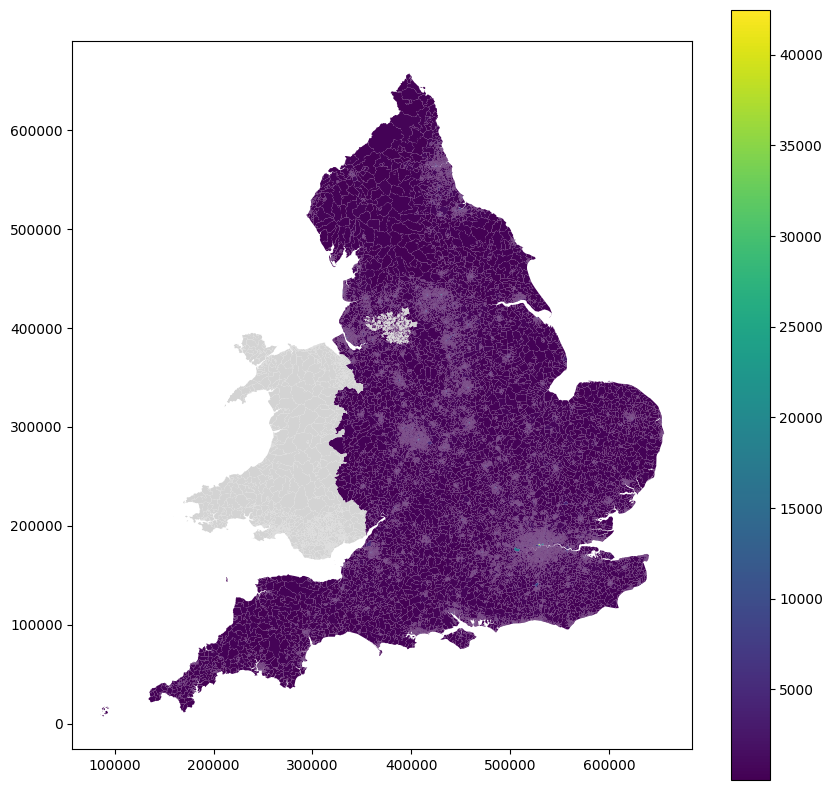

In [33]:
lsoa_location_count.plot(
    column="crime_count",
    cmap="viridis",
    legend=True,
    figsize=(10, 10),
    missing_kwds={"color": "lightgrey"}
)

<Axes: >

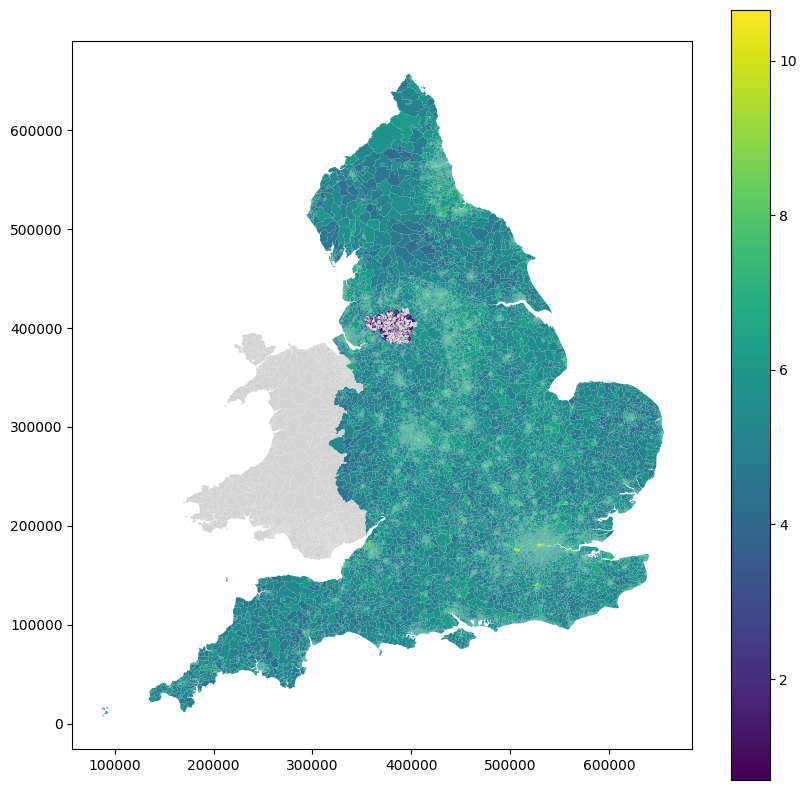

In [34]:
# Logarithmic scale
lsoa_location_count["crime_log"] = np.log1p(lsoa_location_count["crime_count"])

lsoa_location_count.plot(
    column="crime_log",
    cmap="viridis",
    legend=True,
    figsize=(10, 10),
    missing_kwds={"color": "lightgrey"}
)

In [35]:
# Start for a later more informative and interactive map, shows the crime count of each LSOA

m = folium.Map(location=[52.8, -1.5], zoom_start = 6, tiles="cartodbpositron")

folium.Choropleth(
    geo_data=lsoa_location_count.to_crs(4326).to_json(),
    data=lsoa_location_count,
    columns=["LSOA21CD", "crime_count"],
    key_on="feature.properties.LSOA21CD",
    fill_color="YlOrRd",
    fill_opacity=0.4,
    line_opacity=0.1,
    legend_name="Crime count"
).add_to(m)

m.save("normal.html")

In [36]:
# Log version
lsoa_location_count["crime_log"] = np.log1p(lsoa_location_count["crime_count"])

m2 = folium.Map(location=[52.8, -1.5], zoom_start = 6, tiles="cartodbpositron")

folium.Choropleth(
    geo_data=lsoa_location_count.to_crs(4326).to_json(),
    data=lsoa_location_count,
    columns=["LSOA21CD", "crime_log"],
    key_on="feature.properties.LSOA21CD",
    fill_color="YlOrRd",
    fill_opacity=0.4,
    line_opacity=0.1,
    legend_name="Log(Crime count + 1)"
).add_to(m2)

m2.save("log.html")